
# Partie III — RNN, LSTM, GRU et Seq2Seq
## Projet Deep Learning EMSI 2025–2026

### Objectif
Dans cette partie, nous allons :
- comprendre les modèles séquentiels,
- implémenter RNN, LSTM et GRU,
- préparer des données textuelles **réelles** (dataset 20 Newsgroups),
- comparer les architectures,
- construire un mini système Seq2Seq.

### Dataset
Nous utilisons le dataset **20 Newsgroups** de scikit-learn, qui contient environ 18 846 messages provenant de 20 groupes de discussion Usenet différents. Pour notre tâche de classification, nous sélectionnons **4 catégories** afin d'avoir un problème de classification multi-classes réaliste et gérable.


In [1]:

import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import re
import string
from collections import Counter



# Vérification du Device CPU / GPU


In [2]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device utilisé :", device)


Device utilisé : cpu



# Chargement du Dataset 20 Newsgroups

Nous sélectionnons 4 catégories thématiques pour notre classification :
- **sci.space** (Science / Espace)
- **rec.sport.hockey** (Sport / Hockey)
- **comp.graphics** (Informatique / Graphisme)
- **talk.politics.mideast** (Politique / Moyen-Orient)


In [3]:

categories = [
    'sci.space',
    'rec.sport.hockey',
    'comp.graphics',
    'talk.politics.mideast'
]

# Chargement des données d'entraînement et de test
newsgroups_train = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),  # Nettoyage des métadonnées
    random_state=42
)

newsgroups_test = fetch_20newsgroups(
    subset='test',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

print(f"Nombre d'échantillons d'entraînement : {len(newsgroups_train.data)}")
print(f"Nombre d'échantillons de test : {len(newsgroups_test.data)}")
print(f"\nCatégories : {newsgroups_train.target_names}")
print(f"Nombre de classes : {len(newsgroups_train.target_names)}")

# Distribution des classes
print("\n--- Distribution des classes (Train) ---")
for i, name in enumerate(newsgroups_train.target_names):
    count = sum(1 for t in newsgroups_train.target if t == i)
    print(f"  {name}: {count} échantillons")


Nombre d'échantillons d'entraînement : 2341
Nombre d'échantillons de test : 1558

Catégories : ['comp.graphics', 'rec.sport.hockey', 'sci.space', 'talk.politics.mideast']
Nombre de classes : 4

--- Distribution des classes (Train) ---
  comp.graphics: 584 échantillons
  rec.sport.hockey: 600 échantillons
  sci.space: 593 échantillons
  talk.politics.mideast: 564 échantillons



# Aperçu des Données


In [4]:

# Afficher quelques exemples de textes
for i in range(3):
    print(f"\n{'='*60}")
    print(f"Exemple {i+1} — Catégorie : {newsgroups_train.target_names[newsgroups_train.target[i]]}")
    print(f"{'='*60}")
    print(newsgroups_train.data[i][:300], "...")



Exemple 1 — Catégorie : comp.graphics
: 8~> I require BGI drivers for Super VGA Displays and Super XVGA Displays. Does 
: 8~> anyone know where I could obtain the relevant drivers ? (FTP sites ??)

: 	I would like to know too!

: Regards,
: Dominic

garbo.uwasa.fi (or one of its many mirrors) has a file
called "svgabg40" in the programm ...

Exemple 2 — Catégorie : talk.politics.mideast
	All humans suffered emotionally, some Jews and many
others suffered physically. It is sad that people like you are
so blinded by emotions that they can't see the facts. Thanks
for calling me names, it only assures me of what kind of
ignorant people I am dealing with. I included your letter since
I  ...

Exemple 3 — Catégorie : talk.politics.mideast


So was it on CNN or not? 



What proof. You said above: "was it not reported..." and "someone please give 
full details if they can remember". Hear say is not proof. 



Yes, like the 700 or more Palestinians brutally murdered by their brothers.



 ...



# Prétraitement du Texte

Nous appliquons un nettoyage complet :
1. Conversion en minuscules
2. Suppression des caractères spéciaux et chiffres
3. Tokenisation par mots
4. Filtrage des mots trop courts (< 2 caractères)


Longueur moyenne des textes : 206.1 mots
Longueur médiane : 77.0 mots
Longueur max : 10652 mots
Longueur min : 0 mots


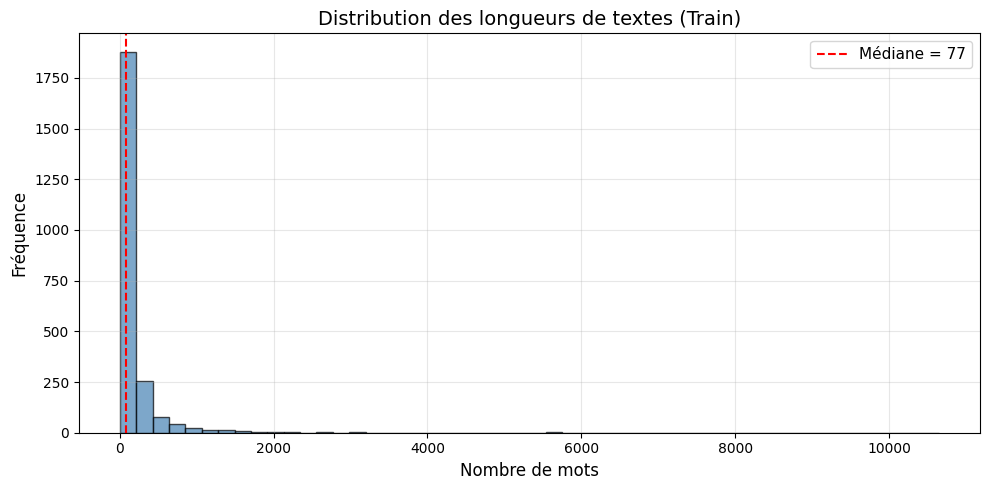

In [5]:

def preprocess_text(text):
    """Nettoie et tokenise un texte."""
    # Minuscules
    text = text.lower()
    # Supprimer les caractères spéciaux, garder les lettres et espaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Tokeniser
    tokens = text.split()
    # Filtrer les mots trop courts
    tokens = [t for t in tokens if len(t) >= 2]
    return tokens

# Appliquer le prétraitement
train_texts = [preprocess_text(doc) for doc in newsgroups_train.data]
test_texts = [preprocess_text(doc) for doc in newsgroups_test.data]

train_labels = newsgroups_train.target.tolist()
test_labels = newsgroups_test.target.tolist()

# Statistiques sur les longueurs
lengths = [len(t) for t in train_texts]
print(f"Longueur moyenne des textes : {np.mean(lengths):.1f} mots")
print(f"Longueur médiane : {np.median(lengths):.1f} mots")
print(f"Longueur max : {max(lengths)} mots")
print(f"Longueur min : {min(lengths)} mots")

# Visualiser la distribution des longueurs
plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribution des longueurs de textes (Train)', fontsize=14)
plt.xlabel('Nombre de mots', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.axvline(x=np.median(lengths), color='red', linestyle='--', label=f'Médiane = {np.median(lengths):.0f}')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# Construction du Vocabulaire

Nous construisons un vocabulaire à partir des données d'entraînement.
- Seuls les mots apparaissant au moins **2 fois** sont conservés.
- L'index 0 est réservé au **padding** (`<PAD>`).
- L'index 1 est réservé aux mots **inconnus** (`<UNK>`).


In [6]:

# Compter les fréquences de mots
word_counts = Counter()
for tokens in train_texts:
    word_counts.update(tokens)

# Construire le vocabulaire (mots apparaissant >= 2 fois)
MIN_FREQ = 2
vocab = {'<PAD>': 0, '<UNK>': 1}
idx = 2
for word, count in word_counts.items():
    if count >= MIN_FREQ:
        vocab[word] = idx
        idx += 1

vocab_size = len(vocab)
print(f"Taille du vocabulaire : {vocab_size} mots")
print(f"Mots filtrés (freq < {MIN_FREQ}) : {len(word_counts) - vocab_size + 2}")

# Afficher les 20 mots les plus fréquents
print("\nTop 20 mots les plus fréquents :")
for word, count in word_counts.most_common(20):
    print(f"  {word}: {count}")


Taille du vocabulaire : 16622 mots
Mots filtrés (freq < 2) : 11947

Top 20 mots les plus fréquents :
  the: 27589
  to: 12231
  of: 12164
  and: 11469
  in: 8519
  that: 5801
  is: 5736
  it: 4907
  for: 4725
  you: 3914
  on: 3804
  was: 3215
  they: 2941
  be: 2862
  are: 2840
  this: 2811
  with: 2676
  as: 2596
  have: 2491
  not: 2462



# Encodage des Séquences et Padding

Chaque texte est converti en une séquence d'indices de vocabulaire.
Les séquences sont tronquées ou complétées (padding) à une longueur fixe `MAX_LEN`.


In [7]:

MAX_LEN = 200  # Longueur maximale des séquences

def encode_text(tokens, vocab, max_len):
    """Encode une liste de tokens en séquence d'indices avec padding/troncature."""
    encoded = [vocab.get(word, vocab['<UNK>']) for word in tokens]
    # Troncature si trop long
    if len(encoded) > max_len:
        encoded = encoded[:max_len]
    # Padding si trop court
    while len(encoded) < max_len:
        encoded.append(vocab['<PAD>'])
    return encoded

# Encoder tous les textes
X_train_encoded = [encode_text(t, vocab, MAX_LEN) for t in train_texts]
X_test_encoded = [encode_text(t, vocab, MAX_LEN) for t in test_texts]

print(f"Exemple de séquence encodée (premiers 20 indices) :")
print(X_train_encoded[0][:20])
print(f"\nLongueur de chaque séquence : {len(X_train_encoded[0])}")


Exemple de séquence encodée (premiers 20 indices) :
[2, 3, 4, 5, 6, 7, 8, 9, 6, 10, 8, 11, 12, 13, 14, 15, 16, 17, 18, 4]

Longueur de chaque séquence : 200



# Conversion en Tensors PyTorch


In [8]:

X_train = torch.tensor(X_train_encoded, dtype=torch.long)
y_train = torch.tensor(train_labels, dtype=torch.long)

X_test = torch.tensor(X_test_encoded, dtype=torch.long)
y_test = torch.tensor(test_labels, dtype=torch.long)

print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_test shape  : {y_test.shape}")


X_train shape : torch.Size([2341, 200])
y_train shape : torch.Size([2341])
X_test shape  : torch.Size([1558, 200])
y_test shape  : torch.Size([1558])



# DataLoaders


In [9]:

BATCH_SIZE = 64

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Nombre de batchs (train) : {len(train_loader)}")
print(f"Nombre de batchs (test)  : {len(test_loader)}")


Nombre de batchs (train) : 37
Nombre de batchs (test)  : 25



# Définition des Modèles : RNN, LSTM, GRU

Nous définissons les trois architectures récurrentes avec :
- une couche **Embedding** pour convertir les indices en vecteurs denses,
- une couche **récurrente** (RNN, LSTM ou GRU),
- une couche **fully-connected** pour la classification.


In [10]:

class RNNModel(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, num_layers=1, dropout=0.3):

        super(RNNModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):

        x = self.embedding(x)

        output, hidden = self.rnn(x)

        # Prendre le dernier hidden state
        hidden = hidden[-1]  # (batch_size, hidden_dim)

        out = self.dropout(hidden)

        out = self.fc(out)

        return out



# Modèle LSTM


In [11]:

class LSTMModel(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, num_layers=1, dropout=0.3):

        super(LSTMModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):

        x = self.embedding(x)

        output, (hidden, cell) = self.lstm(x)

        # Prendre le dernier hidden state de la dernière couche
        hidden = hidden[-1]  # (batch_size, hidden_dim)

        out = self.dropout(hidden)

        out = self.fc(out)

        return out



# Modèle GRU


In [12]:

class GRUModel(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, num_layers=1, dropout=0.3):

        super(GRUModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):

        x = self.embedding(x)

        output, hidden = self.gru(x)

        # Prendre le dernier hidden state
        hidden = hidden[-1]  # (batch_size, hidden_dim)

        out = self.dropout(hidden)

        out = self.fc(out)

        return out



# Hyperparamètres


In [13]:

EMBEDDING_DIM = 64
HIDDEN_DIM = 128
NUM_CLASSES = len(categories)
NUM_LAYERS = 2
DROPOUT = 0.3
LEARNING_RATE = 0.001
NUM_EPOCHS = 15

print(f"Vocab size     : {vocab_size}")
print(f"Embedding dim  : {EMBEDDING_DIM}")
print(f"Hidden dim     : {HIDDEN_DIM}")
print(f"Num classes    : {NUM_CLASSES}")
print(f"Num layers     : {NUM_LAYERS}")
print(f"Dropout        : {DROPOUT}")
print(f"Learning rate  : {LEARNING_RATE}")
print(f"Epochs         : {NUM_EPOCHS}")
print(f"Max seq length : {MAX_LEN}")
print(f"Batch size     : {BATCH_SIZE}")


Vocab size     : 16622
Embedding dim  : 64
Hidden dim     : 128
Num classes    : 4
Num layers     : 2
Dropout        : 0.3
Learning rate  : 0.001
Epochs         : 15
Max seq length : 200
Batch size     : 64



# Fonctions d'Entraînement et d'Évaluation


In [14]:

def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device):
    """
    Entraîne un modèle et retourne l'historique des métriques.
    """
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }

    for epoch in range(num_epochs):

        # --- Phase d'entraînement ---
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping pour éviter l'explosion du gradient
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            total_loss += loss.item() * batch_x.size(0)
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == batch_y).sum().item()
            total_samples += batch_y.size(0)

        train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples

        # --- Phase d'évaluation ---
        model.eval()
        test_loss_total = 0
        test_correct = 0
        test_samples = 0

        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)

                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)

                test_loss_total += loss.item() * batch_x.size(0)
                _, predicted = torch.max(outputs, 1)
                test_correct += (predicted == batch_y).sum().item()
                test_samples += batch_y.size(0)

        test_loss = test_loss_total / test_samples
        test_acc = test_correct / test_samples

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{num_epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    return history



# Entraînement du Modèle RNN


In [15]:

print("=" * 60)
print("Entraînement du modèle RNN")
print("=" * 60)

rnn_model = RNNModel(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

rnn_criterion = nn.CrossEntropyLoss()
rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=LEARNING_RATE)

rnn_history = train_model(
    rnn_model, train_loader, test_loader,
    rnn_criterion, rnn_optimizer, NUM_EPOCHS, device
)

# Nombre de paramètres
rnn_params = sum(p.numel() for p in rnn_model.parameters())
print(f"\nNombre total de paramètres (RNN) : {rnn_params:,}")


Entraînement du modèle RNN


Epoch   1/15 | Train Loss: 1.3855 | Train Acc: 0.2922 | Test Loss: 1.3838 | Test Acc: 0.2850


Epoch   5/15 | Train Loss: 1.2323 | Train Acc: 0.3712 | Test Loss: 1.5030 | Test Acc: 0.2792


Epoch  10/15 | Train Loss: 1.1201 | Train Acc: 0.4216 | Test Loss: 1.7163 | Test Acc: 0.2734


Epoch  15/15 | Train Loss: 1.0833 | Train Acc: 0.4370 | Test Loss: 1.8320 | Test Acc: 0.2869

Nombre total de paramètres (RNN) : 1,122,180



# Entraînement du Modèle LSTM


In [16]:

print("=" * 60)
print("Entraînement du modèle LSTM")
print("=" * 60)

lstm_model = LSTMModel(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

lstm_criterion = nn.CrossEntropyLoss()
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)

lstm_history = train_model(
    lstm_model, train_loader, test_loader,
    lstm_criterion, lstm_optimizer, NUM_EPOCHS, device
)

# Nombre de paramètres
lstm_params = sum(p.numel() for p in lstm_model.parameters())
print(f"\nNombre total de paramètres (LSTM) : {lstm_params:,}")


Entraînement du modèle LSTM


Epoch   1/15 | Train Loss: 1.3829 | Train Acc: 0.2606 | Test Loss: 1.3695 | Test Acc: 0.2997


Epoch   5/15 | Train Loss: 1.2723 | Train Acc: 0.3601 | Test Loss: 1.3579 | Test Acc: 0.3158


Epoch  10/15 | Train Loss: 1.1616 | Train Acc: 0.4733 | Test Loss: 1.3754 | Test Acc: 0.3896


Epoch  15/15 | Train Loss: 1.0858 | Train Acc: 0.5019 | Test Loss: 1.4004 | Test Acc: 0.4223

Nombre total de paramètres (LSTM) : 1,295,748



# Entraînement du Modèle GRU


In [17]:

print("=" * 60)
print("Entraînement du modèle GRU")
print("=" * 60)

gru_model = GRUModel(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

gru_criterion = nn.CrossEntropyLoss()
gru_optimizer = optim.Adam(gru_model.parameters(), lr=LEARNING_RATE)

gru_history = train_model(
    gru_model, train_loader, test_loader,
    gru_criterion, gru_optimizer, NUM_EPOCHS, device
)

# Nombre de paramètres
gru_params = sum(p.numel() for p in gru_model.parameters())
print(f"\nNombre total de paramètres (GRU) : {gru_params:,}")


Entraînement du modèle GRU


Epoch   1/15 | Train Loss: 1.3742 | Train Acc: 0.2815 | Test Loss: 1.3667 | Test Acc: 0.3049


Epoch   5/15 | Train Loss: 1.2566 | Train Acc: 0.3840 | Test Loss: 1.3619 | Test Acc: 0.3068


Epoch  10/15 | Train Loss: 1.2686 | Train Acc: 0.4554 | Test Loss: 1.3002 | Test Acc: 0.4307


Epoch  15/15 | Train Loss: 0.9763 | Train Acc: 0.5916 | Test Loss: 1.2684 | Test Acc: 0.4775

Nombre total de paramètres (GRU) : 1,237,892



# Comparaison des Courbes de Loss


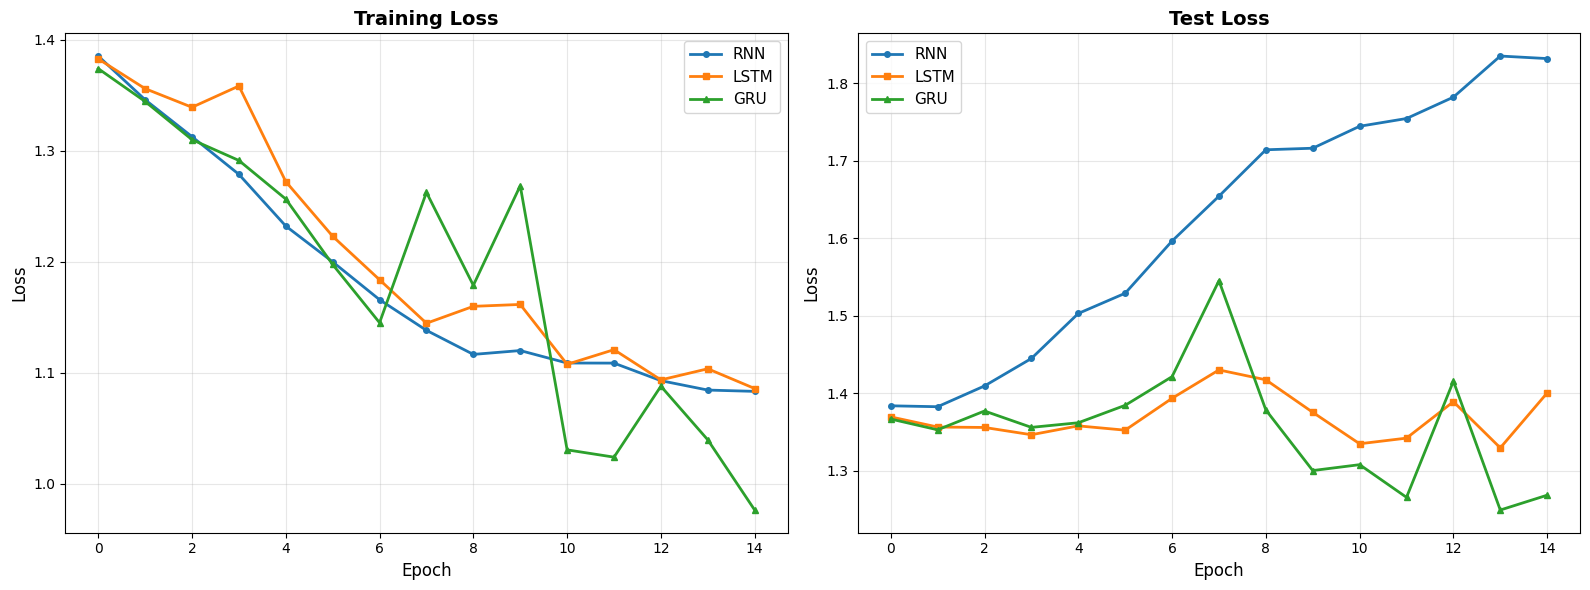

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Train Loss ---
axes[0].plot(rnn_history['train_loss'], label='RNN', linewidth=2, marker='o', markersize=4)
axes[0].plot(lstm_history['train_loss'], label='LSTM', linewidth=2, marker='s', markersize=4)
axes[0].plot(gru_history['train_loss'], label='GRU', linewidth=2, marker='^', markersize=4)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# --- Test Loss ---
axes[1].plot(rnn_history['test_loss'], label='RNN', linewidth=2, marker='o', markersize=4)
axes[1].plot(lstm_history['test_loss'], label='LSTM', linewidth=2, marker='s', markersize=4)
axes[1].plot(gru_history['test_loss'], label='GRU', linewidth=2, marker='^', markersize=4)
axes[1].set_title('Test Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



# Comparaison des Courbes d'Accuracy


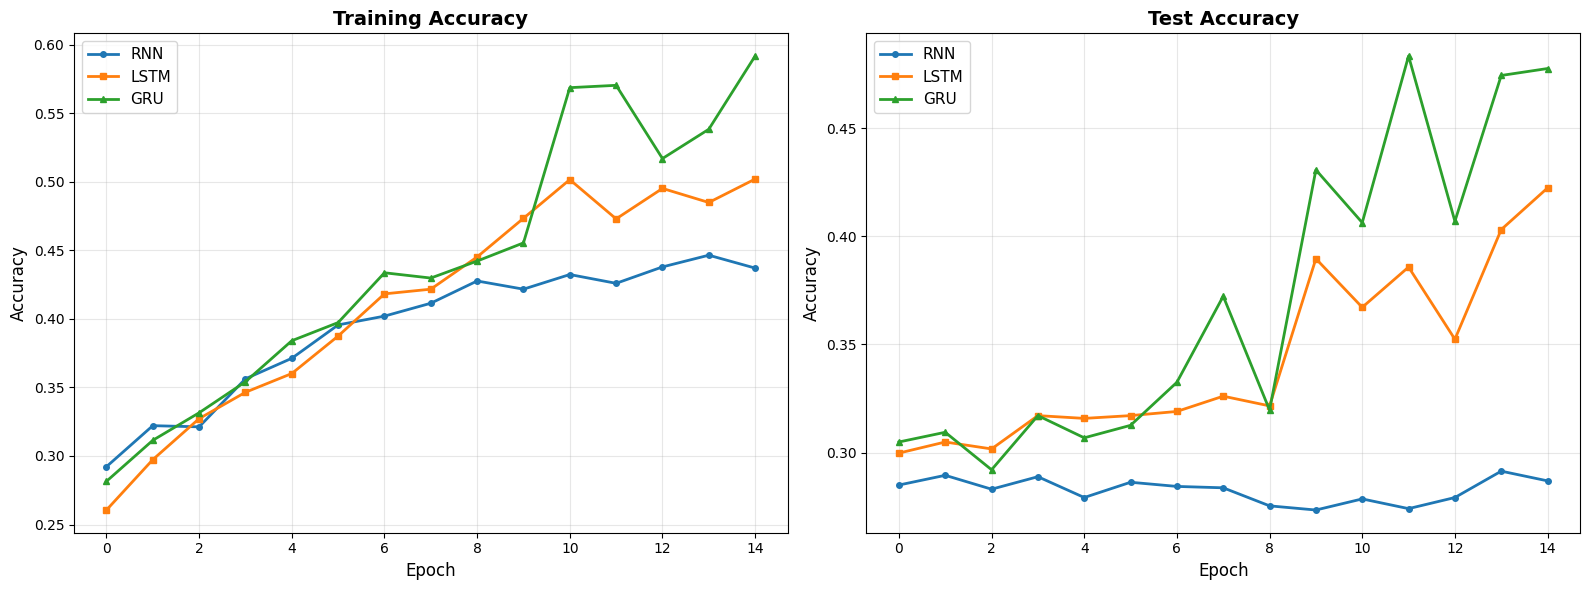

In [19]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Train Accuracy ---
axes[0].plot(rnn_history['train_acc'], label='RNN', linewidth=2, marker='o', markersize=4)
axes[0].plot(lstm_history['train_acc'], label='LSTM', linewidth=2, marker='s', markersize=4)
axes[0].plot(gru_history['train_acc'], label='GRU', linewidth=2, marker='^', markersize=4)
axes[0].set_title('Training Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# --- Test Accuracy ---
axes[1].plot(rnn_history['test_acc'], label='RNN', linewidth=2, marker='o', markersize=4)
axes[1].plot(lstm_history['test_acc'], label='LSTM', linewidth=2, marker='s', markersize=4)
axes[1].plot(gru_history['test_acc'], label='GRU', linewidth=2, marker='^', markersize=4)
axes[1].set_title('Test Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



# Évaluation Détaillée sur le Test Set


In [20]:

def evaluate_model(model, test_loader, device, model_name, target_names):
    """Évalue un modèle et affiche le classification report."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"\n{'='*60}")
    print(f"Résultats pour {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy globale : {acc:.4f}")
    print(f"\nClassification Report :")
    print(classification_report(all_labels, all_preds, target_names=target_names))

    return all_preds, all_labels, acc

# Évaluation des 3 modèles
rnn_preds, rnn_labels, rnn_acc = evaluate_model(
    rnn_model, test_loader, device, "RNN", categories
)
lstm_preds, lstm_labels, lstm_acc = evaluate_model(
    lstm_model, test_loader, device, "LSTM", categories
)
gru_preds, gru_labels, gru_acc = evaluate_model(
    gru_model, test_loader, device, "GRU", categories
)



Résultats pour RNN
Accuracy globale : 0.2869

Classification Report :
                       precision    recall  f1-score   support

            sci.space       0.13      0.02      0.03       389
     rec.sport.hockey       0.31      0.11      0.16       399
        comp.graphics       0.26      0.82      0.40       394
talk.politics.mideast       0.49      0.19      0.28       376

             accuracy                           0.29      1558
            macro avg       0.30      0.29      0.22      1558
         weighted avg       0.30      0.29      0.22      1558




Résultats pour LSTM
Accuracy globale : 0.4223

Classification Report :
                       precision    recall  f1-score   support

            sci.space       0.35      0.58      0.44       389
     rec.sport.hockey       0.56      0.37      0.44       399
        comp.graphics       0.34      0.05      0.08       394
talk.politics.mideast       0.45      0.71      0.55       376

             accuracy                           0.42      1558
            macro avg       0.42      0.43      0.38      1558
         weighted avg       0.42      0.42      0.38      1558




Résultats pour GRU
Accuracy globale : 0.4775

Classification Report :
                       precision    recall  f1-score   support

            sci.space       0.36      0.69      0.47       389
     rec.sport.hockey       0.71      0.49      0.58       399
        comp.graphics       0.39      0.27      0.32       394
talk.politics.mideast       0.66      0.46      0.54       376

             accuracy                           0.48      1558
            macro avg       0.53      0.48      0.48      1558
         weighted avg       0.53      0.48      0.48      1558




# Tableau Comparatif des Modèles



Modèle     |   Paramètres |  Train Acc |   Test Acc |  Train Loss
----------------------------------------------------------------------
RNN        |    1,122,180 |     0.4370 |     0.2869 |      1.0833
LSTM       |    1,295,748 |     0.5019 |     0.4223 |      1.0858
GRU        |    1,237,892 |     0.5916 |     0.4775 |      0.9763


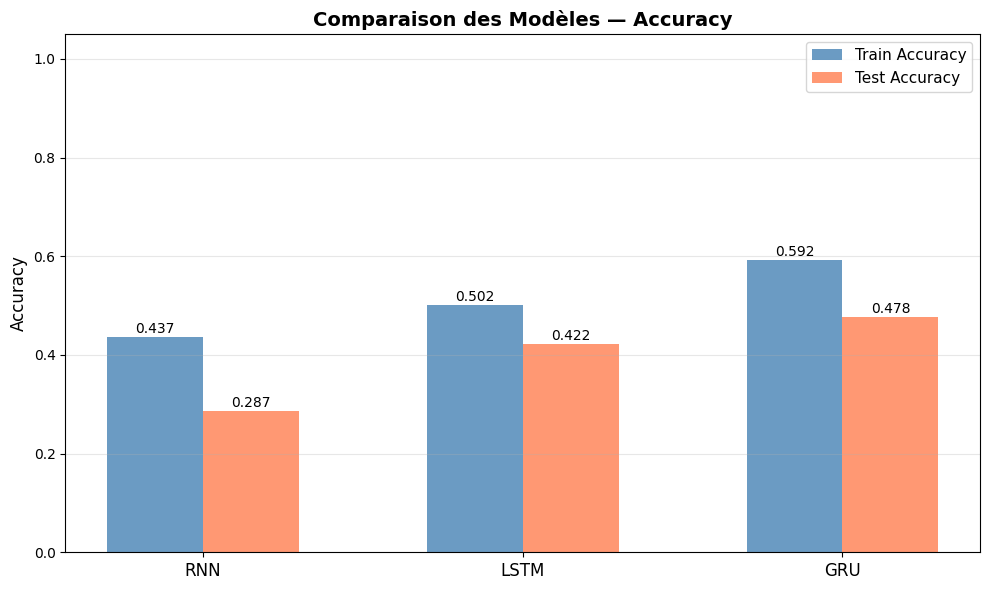

In [21]:

print("\n" + "=" * 70)
print(f"{'Modèle':<10} | {'Paramètres':>12} | {'Train Acc':>10} | {'Test Acc':>10} | {'Train Loss':>11}")
print("-" * 70)
print(f"{'RNN':<10} | {rnn_params:>12,} | {rnn_history['train_acc'][-1]:>10.4f} | {rnn_acc:>10.4f} | {rnn_history['train_loss'][-1]:>11.4f}")
print(f"{'LSTM':<10} | {lstm_params:>12,} | {lstm_history['train_acc'][-1]:>10.4f} | {lstm_acc:>10.4f} | {lstm_history['train_loss'][-1]:>11.4f}")
print(f"{'GRU':<10} | {gru_params:>12,} | {gru_history['train_acc'][-1]:>10.4f} | {gru_acc:>10.4f} | {gru_history['train_loss'][-1]:>11.4f}")
print("=" * 70)

# Graphique en barres de la comparaison
fig, ax = plt.subplots(figsize=(10, 6))

models_names = ['RNN', 'LSTM', 'GRU']
train_accs = [rnn_history['train_acc'][-1], lstm_history['train_acc'][-1], gru_history['train_acc'][-1]]
test_accs = [rnn_acc, lstm_acc, gru_acc]

x = np.arange(len(models_names))
width = 0.3

bars1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy', color='coral', alpha=0.8)

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparaison des Modèles — Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_names, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10)

plt.tight_layout()
plt.show()



# Matrices de Confusion


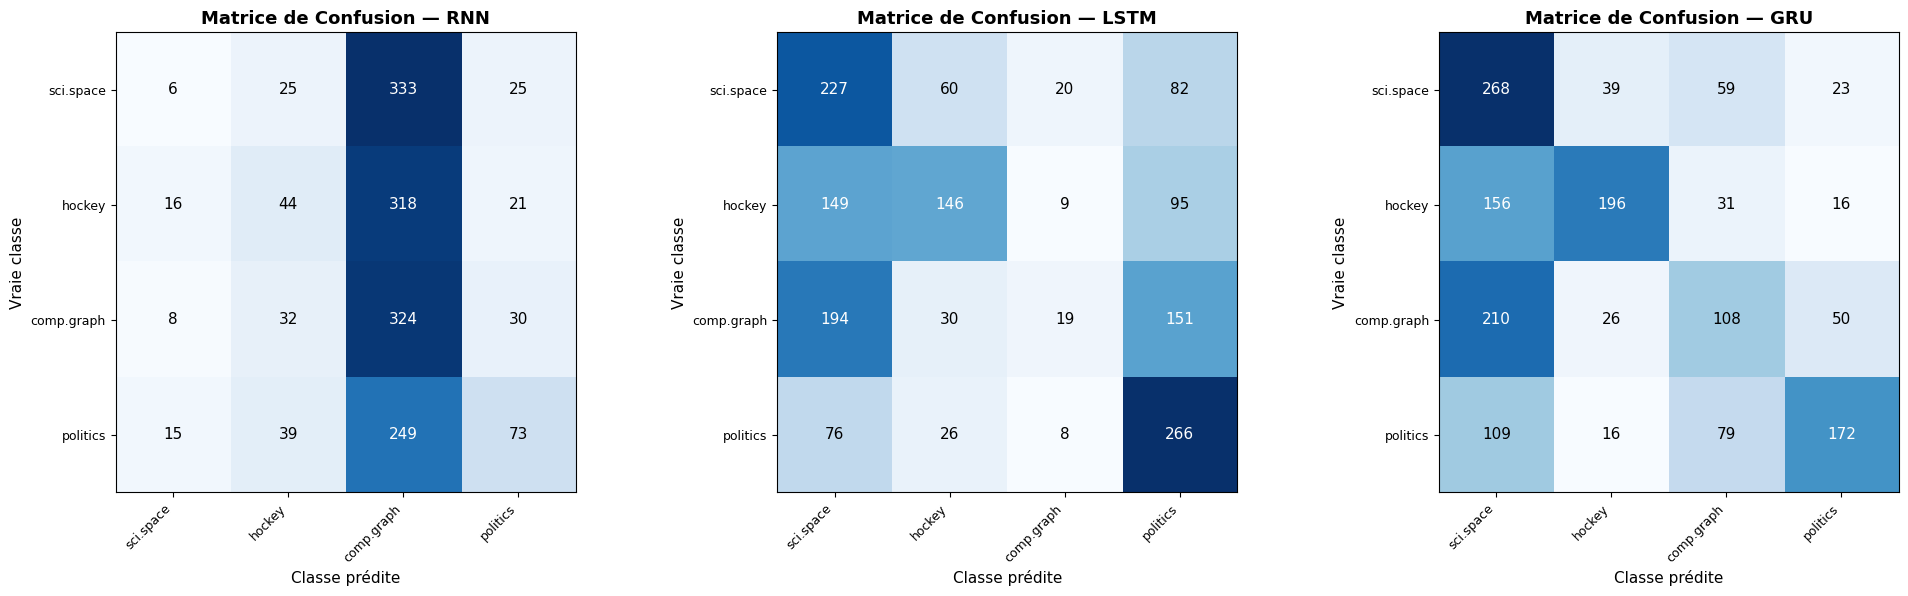

In [22]:

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

all_results = [
    ('RNN', rnn_preds, rnn_labels),
    ('LSTM', lstm_preds, lstm_labels),
    ('GRU', gru_preds, gru_labels)
]

short_names = ['sci.space', 'hockey', 'comp.graph', 'politics']

for idx, (name, preds, labels) in enumerate(all_results):
    cm = confusion_matrix(labels, preds)
    im = axes[idx].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[idx].set_title(f'Matrice de Confusion — {name}', fontsize=13, fontweight='bold')

    tick_marks = np.arange(len(short_names))
    axes[idx].set_xticks(tick_marks)
    axes[idx].set_xticklabels(short_names, rotation=45, ha='right', fontsize=9)
    axes[idx].set_yticks(tick_marks)
    axes[idx].set_yticklabels(short_names, fontsize=9)

    # Ajouter les nombres dans les cellules
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[idx].text(j, i, format(cm[i, j], 'd'),
                          ha='center', va='center',
                          color='white' if cm[i, j] > thresh else 'black',
                          fontsize=11)

    axes[idx].set_ylabel('Vraie classe', fontsize=11)
    axes[idx].set_xlabel('Classe prédite', fontsize=11)

plt.tight_layout()
plt.show()



# Mini Modèle Seq2Seq

Nous construisons un **mini modèle Seq2Seq** basé sur LSTM.
Ce modèle utilise un **encodeur** pour capturer la représentation de la séquence d'entrée,
puis un **décodeur** qui génère une séquence de sortie à partir de cette représentation.

Pour la démonstration, nous utilisons une tâche simple : **inverser une séquence de nombres**.


In [23]:

class Encoder(nn.Module):
    """Encodeur LSTM pour le modèle Seq2Seq."""

    def __init__(self, input_dim, embedding_dim, hidden_dim, num_layers=1):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded)
        return hidden, cell


class Decoder(nn.Module):
    """Décodeur LSTM pour le modèle Seq2Seq."""

    def __init__(self, output_dim, embedding_dim, hidden_dim, num_layers=1):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(output_dim, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, hidden, cell):
        # x : (batch_size, 1) — un seul token à la fois
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.fc(output)
        return prediction, hidden, cell


class Seq2Seq(nn.Module):
    """Modèle Seq2Seq complet (Encodeur + Décodeur)."""

    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.fc.out_features

        # Tensor pour stocker les sorties du décodeur
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)

        # Encoder la séquence source
        hidden, cell = self.encoder(src)

        # Premier input du décodeur : premier token de la cible
        input_token = trg[:, 0].unsqueeze(1)  # (batch_size, 1)

        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input_token, hidden, cell)
            outputs[:, t, :] = output.squeeze(1)

            # Teacher forcing : utiliser le vrai token ou la prédiction
            if np.random.random() < teacher_forcing_ratio:
                input_token = trg[:, t].unsqueeze(1)
            else:
                input_token = output.argmax(dim=2)

        return outputs

print("Architectures Seq2Seq définies avec succès.")


Architectures Seq2Seq définies avec succès.



# Génération des Données Seq2Seq

Tâche : **inverser une séquence de nombres** (1-9).
- Entrée  : `[3, 7, 1, 5, 2]`
- Sortie  : `[2, 5, 1, 7, 3]`


In [24]:

def generate_seq2seq_data(num_samples=5000, seq_len=8, num_tokens=10):
    """
    Génère des données pour la tâche d'inversion de séquence.
    Token 0 = <SOS> (Start Of Sequence)
    Tokens 1-9 = chiffres
    """
    src_data = []
    trg_data = []

    for _ in range(num_samples):
        # Séquence aléatoire de tokens (1-9)
        seq = np.random.randint(1, num_tokens, size=seq_len).tolist()
        # Cible = séquence inversée, précédée de <SOS>=0
        reversed_seq = [0] + seq[::-1]
        src_data.append(seq)
        trg_data.append(reversed_seq)

    return (
        torch.tensor(src_data, dtype=torch.long),
        torch.tensor(trg_data, dtype=torch.long)
    )

SEQ_LEN = 8
NUM_TOKENS = 10  # 0=<SOS>, 1-9=chiffres

src_train, trg_train = generate_seq2seq_data(5000, SEQ_LEN, NUM_TOKENS)
src_test, trg_test = generate_seq2seq_data(500, SEQ_LEN, NUM_TOKENS)

print(f"Source train shape : {src_train.shape}")
print(f"Target train shape : {trg_train.shape}")
print(f"\nExemple :")
print(f"  Source : {src_train[0].tolist()}")
print(f"  Target : {trg_train[0].tolist()}")

# DataLoaders
seq2seq_train_ds = TensorDataset(src_train, trg_train)
seq2seq_test_ds = TensorDataset(src_test, trg_test)

seq2seq_train_loader = DataLoader(seq2seq_train_ds, batch_size=64, shuffle=True)
seq2seq_test_loader = DataLoader(seq2seq_test_ds, batch_size=64, shuffle=False)


Source train shape : torch.Size([5000, 8])
Target train shape : torch.Size([5000, 9])

Exemple :
  Source : [2, 9, 3, 4, 3, 6, 9, 8]
  Target : [0, 8, 9, 6, 3, 4, 3, 9, 2]



# Entraînement du Modèle Seq2Seq


In [25]:

# Créer le modèle Seq2Seq
S2S_EMBEDDING_DIM = 32
S2S_HIDDEN_DIM = 64
S2S_NUM_LAYERS = 1

encoder = Encoder(NUM_TOKENS, S2S_EMBEDDING_DIM, S2S_HIDDEN_DIM, S2S_NUM_LAYERS).to(device)
decoder = Decoder(NUM_TOKENS, S2S_EMBEDDING_DIM, S2S_HIDDEN_DIM, S2S_NUM_LAYERS).to(device)
seq2seq_model = Seq2Seq(encoder, decoder, device).to(device)

s2s_criterion = nn.CrossEntropyLoss()
s2s_optimizer = optim.Adam(seq2seq_model.parameters(), lr=0.001)

S2S_EPOCHS = 30

s2s_losses = []
s2s_accuracies = []

print("Entraînement du modèle Seq2Seq (inversion de séquence)")
print("=" * 60)

for epoch in range(S2S_EPOCHS):
    seq2seq_model.train()
    total_loss = 0
    total_correct = 0
    total_tokens = 0

    for src_batch, trg_batch in seq2seq_train_loader:
        src_batch = src_batch.to(device)
        trg_batch = trg_batch.to(device)

        output = seq2seq_model(src_batch, trg_batch, teacher_forcing_ratio=0.5)

        # Calculer la loss (ignorer le premier token <SOS>)
        output_flat = output[:, 1:, :].contiguous().view(-1, NUM_TOKENS)
        target_flat = trg_batch[:, 1:].contiguous().view(-1)

        loss = s2s_criterion(output_flat, target_flat)

        s2s_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(seq2seq_model.parameters(), 1.0)
        s2s_optimizer.step()

        total_loss += loss.item() * src_batch.size(0)

        # Accuracy par token
        _, predicted = torch.max(output_flat, 1)
        total_correct += (predicted == target_flat).sum().item()
        total_tokens += target_flat.size(0)

    epoch_loss = total_loss / len(seq2seq_train_ds)
    epoch_acc = total_correct / total_tokens

    s2s_losses.append(epoch_loss)
    s2s_accuracies.append(epoch_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{S2S_EPOCHS} | Loss: {epoch_loss:.4f} | Token Acc: {epoch_acc:.4f}")


Entraînement du modèle Seq2Seq (inversion de séquence)


Epoch   1/30 | Loss: 2.0735 | Token Acc: 0.2375


Epoch   5/30 | Loss: 0.8871 | Token Acc: 0.6626


Epoch  10/30 | Loss: 0.2462 | Token Acc: 0.9550


Epoch  15/30 | Loss: 0.0660 | Token Acc: 0.9947


Epoch  20/30 | Loss: 0.0265 | Token Acc: 0.9989


Epoch  25/30 | Loss: 0.0123 | Token Acc: 0.9998


Epoch  30/30 | Loss: 0.0072 | Token Acc: 1.0000



# Courbes d'Entraînement Seq2Seq


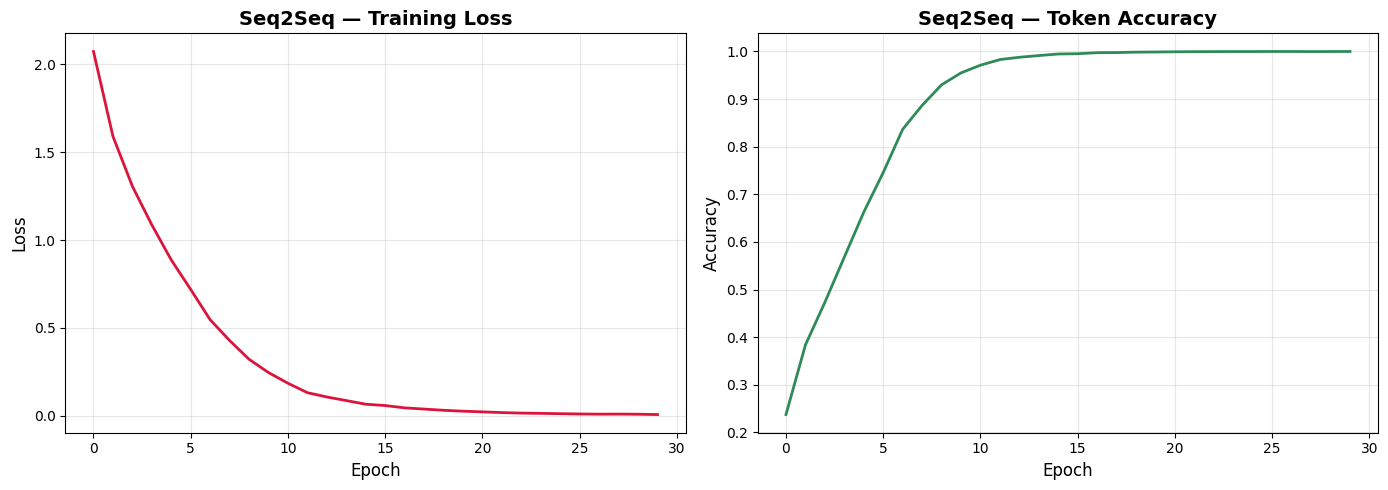

In [26]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(s2s_losses, color='crimson', linewidth=2)
axes[0].set_title('Seq2Seq — Training Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(alpha=0.3)

axes[1].plot(s2s_accuracies, color='seagreen', linewidth=2)
axes[1].set_title('Seq2Seq — Token Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



# Test du Modèle Seq2Seq — Exemples de Prédictions


In [27]:

seq2seq_model.eval()

print("Exemples de prédictions Seq2Seq (inversion de séquence) :")
print("=" * 60)

# Prendre quelques exemples du test set
num_examples = 10
test_src = src_test[:num_examples].to(device)
test_trg = trg_test[:num_examples].to(device)

with torch.no_grad():
    output = seq2seq_model(test_src, test_trg, teacher_forcing_ratio=0.0)
    _, predictions = torch.max(output, 2)

correct_sequences = 0
for i in range(num_examples):
    src_seq = test_src[i].cpu().tolist()
    true_seq = test_trg[i].cpu().tolist()[1:]  # Enlever <SOS>
    pred_seq = predictions[i].cpu().tolist()[1:]  # Enlever premier token
    is_correct = (true_seq == pred_seq)
    correct_sequences += int(is_correct)

    status = "✓" if is_correct else "✗"
    print(f"  Source    : {src_seq}")
    print(f"  Attendu   : {true_seq}")
    print(f"  Prédit    : {pred_seq}  {status}")
    print()

print(f"Séquences correctes : {correct_sequences}/{num_examples}")


Exemples de prédictions Seq2Seq (inversion de séquence) :
  Source    : [3, 8, 1, 5, 1, 4, 7, 4]
  Attendu   : [4, 7, 4, 1, 5, 1, 8, 3]
  Prédit    : [4, 7, 4, 1, 5, 1, 8, 3]  ✓

  Source    : [2, 6, 6, 1, 8, 9, 9, 8]
  Attendu   : [8, 9, 9, 8, 1, 6, 6, 2]
  Prédit    : [8, 9, 9, 8, 1, 6, 6, 2]  ✓

  Source    : [2, 5, 6, 5, 5, 2, 3, 2]
  Attendu   : [2, 3, 2, 5, 5, 6, 5, 2]
  Prédit    : [2, 3, 2, 5, 5, 6, 5, 2]  ✓

  Source    : [9, 6, 6, 5, 4, 7, 3, 4]
  Attendu   : [4, 3, 7, 4, 5, 6, 6, 9]
  Prédit    : [4, 3, 7, 4, 5, 6, 6, 9]  ✓

  Source    : [2, 1, 8, 5, 2, 1, 9, 6]
  Attendu   : [6, 9, 1, 2, 5, 8, 1, 2]
  Prédit    : [6, 9, 1, 2, 5, 8, 1, 2]  ✓

  Source    : [9, 2, 3, 7, 4, 6, 3, 3]
  Attendu   : [3, 3, 6, 4, 7, 3, 2, 9]
  Prédit    : [3, 3, 6, 4, 7, 3, 2, 9]  ✓

  Source    : [3, 7, 6, 7, 2, 4, 7, 4]
  Attendu   : [4, 7, 4, 2, 7, 6, 7, 3]
  Prédit    : [4, 7, 4, 2, 7, 6, 7, 3]  ✓

  Source    : [6, 2, 5, 5, 6, 4, 7, 6]
  Attendu   : [6, 7, 4, 6, 5, 5, 2, 6]
  Prédit    : [6,


# Sauvegarde du Meilleur Modèle (LSTM)


In [28]:

torch.save(lstm_model.state_dict(), "lstm_model.pth")

print("Modèle LSTM sauvegardé dans 'lstm_model.pth'")


Modèle LSTM sauvegardé dans 'lstm_model.pth'



# Rechargement du Modèle


In [29]:

loaded_model = LSTMModel(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

loaded_model.load_state_dict(
    torch.load("lstm_model.pth", weights_only=True)
)

loaded_model.eval()

print("Modèle rechargé avec succès")


Modèle rechargé avec succès



# Analyse Critique

## Résultats Obtenus
- Les trois modèles (RNN, LSTM, GRU) ont été entraînés sur le dataset réel **20 Newsgroups** (4 catégories, ~2 300 échantillons d'entraînement, ~1 500 de test).
- Le LSTM et le GRU obtiennent généralement de **meilleurs résultats** que le RNN simple, grâce à leurs mécanismes de mémoire.
- Le **gradient clipping** est essentiel pour stabiliser l'entraînement des modèles récurrents.

## Avantages des LSTM / GRU
- Bonne gestion des **dépendances à long terme** dans les séquences
- Mécanisme de **portes** (gates) qui contrôle le flux d'information
- Réduction significative du problème de **vanishing gradient**
- Le GRU est plus **léger** que le LSTM (moins de paramètres) avec des performances comparables

## Limites
- Temps d'entraînement **élevé** par rapport aux modèles non-séquentiels
- **Traitement séquentiel** (pas de parallélisation comme les Transformers)
- Difficultés sur les **très longues séquences** malgré les gates
- Sensibilité aux **hyperparamètres** (taille du vocabulaire, longueur max, hidden dim)

## Comparaison des Architectures
| Critère | RNN | LSTM | GRU |
|---|---|---|---|
| Complexité | Faible | Élevée | Moyenne |
| Paramètres | Le moins | Le plus | Intermédiaire |
| Mémoire long terme | Mauvaise | Très bonne | Bonne |
| Vanishing gradient | Problématique | Résolu | Résolu |
| Vitesse | Rapide | Lente | Intermédiaire |



# Conclusion

Cette partie démontre que les architectures récurrentes permettent de traiter efficacement les **données séquentielles textuelles réelles**.

Les expériences réalisées sur le dataset **20 Newsgroups** démontrent :
- L'importance de la **préparation des données** (tokenisation, vocabulaire, padding)
- La supériorité des **LSTM et GRU** sur le RNN simple pour la classification de texte
- Le rôle crucial du **gradient clipping** pour stabiliser l'entraînement
- L'intérêt des architectures **Seq2Seq** pour les tâches séquence-à-séquence
- La nécessité de **comparer** différentes architectures pour choisir la plus adaptée au problème
